/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
Removed no burn in
Saved: planck_omegam_w.png


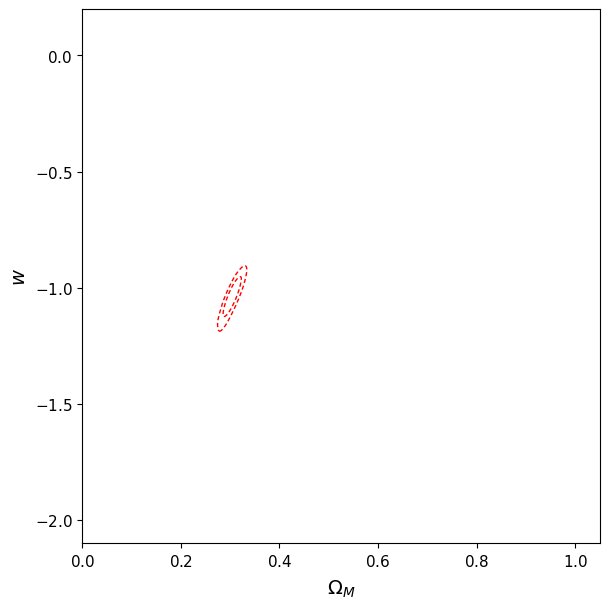

In [6]:
# pip install getdist matplotlib
from getdist.mcsamples import loadMCSamples
from getdist import plots

planck_root = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO"
# 如果要带 CMB lensing，root 换成 ..._post_lensing

def ensure_omegam_and_w(samples):
    """确保有 omegam 和 w（若无就由链里字段派生）"""
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    # w
    if 'w' not in names and hasattr(P, 'w0'):
        samples.addDerived(P.w0, name='w', label='w')

    # omegam
    names = {p.name for p in samples.getParamNames().names}
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2, name='omegam', label=r'\Omega_M')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2, name='omegam', label=r'\Omega_M')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_M')

    # 统一标签
    try: samples.setLabel('omegam', r'\Omega_M')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

planck = loadMCSamples(planck_root, settings={'ignore_rows':0.3}, no_cache=True)
planck = ensure_omegam_and_w(planck)

# 画 ΩM-w 等高线（68/95%）
g = plots.get_subplot_plotter(width_inch=6.2)
g.settings.num_plot_contours = 2
g.plot_2d([planck], ['omegam','w'],
          filled=False, colors=['red'],
          line_args=[{'ls':'--','lw':1.0}],
          legend_labels=['Planck CMB + BAO'])

ax = g.subplots[0,0]
ax.set_xlim(0.0, 1.05)
ax.set_ylim(-2.1, 0.2)
ax.set_xlabel(r'$\Omega_M$'); ax.set_ylabel(r'$w$')

g.export('planck_omegam_w.png')
print('Saved: planck_omegam_w.png')


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
Removed no burn in
Removed no burn in

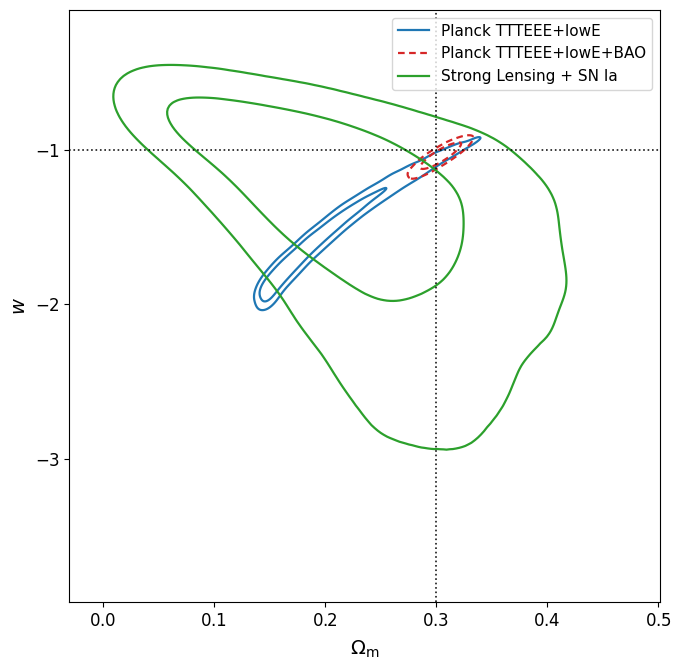

In [3]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------------- Planck roots (wCDM) ----------------
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w"  # 如需改成别的（例如 base_w_wa），改这里

root_nobao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE"
)
root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
# 若需 CMB lensing，把上面两个 root 改成 *_post_lensing 版本

# ---------------- 本地链设置 ----------------
base_dir = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
# local_pairs = [("linear", "Tri"), ("linear", "0.22")]  
local_pairs = [("linear", "0.22")]  
local_col_order = ('omegam', 'w')  # 若本地链顺序为 (w, Ωm) 则改为 ('w','omegam')

# ---------------- 工具函数 ----------------
def ensure_omegam_and_w(samples):
    """确保 Planck 样本里有 omegam 与 w（若 w0 存在则派生 w），并设置合适标签（GetDist 标签不要加 $）"""
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    # w
    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        elif hasattr(P, 'w'):
            pass
        else:
            raise RuntimeError("此 Planck 链未包含 w/w0；请改用 base_w 类链或相应 root。")

    # Ωm
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_{\rm m}')

    try: samples.setLabel('omegam', r'\Omega_{\rm m}')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w')):
    """
    将本地 numpy 链转为 MCSamples。
    order 指定列的物理含义与输出顺序（'omegam'/'w' 的排列）。
    """
    # 展平并去掉 burn-in
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
        ndim = flat.shape[-1]

    if set(order) != {'omegam','w'} or len(order) != 2:
        raise ValueError("order 必须是 ('omegam','w') 或 ('w','omegam')")

    # 如果实际列顺序与 order 不符，这里交换
    # 假设原始列为 [Ωm, w]；若 order=('w','omegam') 则交换：
    if order == ('w', 'omegam'):
        flat = flat[:, [1, 0]]

    # 用标准内部名字 + 无 $ 的标签
    names  = ['omegam', 'w']
    labels = [r'\Omega_{\rm m}', 'w']
    mcs = MCSamples(samples=flat, names=names, labels=labels)
    # 可选：再设置 chain 级别的显示名（用于图例）；由外部赋值更灵活
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    """汇总多组样本求统一坐标轴范围（分位数+边距）"""
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ---------------- 加载 Planck 链 ----------------
planck_nobao = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_nobao = ensure_omegam_and_w(planck_nobao)

planck_bao = loadMCSamples(root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_omegam_and_w(planck_bao)

# ---------------- 加载本地链（linear + Tri / 0.22） ----------------
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop2D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy_to_mcsamples(arr, burnin_frac=0.30, order=local_col_order)
    mcs.label = f"{evo} + {prior}"
    local_mcs.append(mcs)

# ---------------- 画 Ωm – w，四套等高线 ----------------
all_samples = [planck_nobao, planck_bao] + local_mcs
legend_labels = [
    r'Planck TTTEEE+lowE',
    r'Planck TTTEEE+lowE+BAO',
    # r'Lensing (linear + Tri)',
    r'Strong Lensing + SN Ia',
]

colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']  # 蓝/红/绿/紫
line_args = [
    {'ls': '-',  'lw': 1.6},   # Planck nobao
    {'ls': '--', 'lw': 1.6},   # Planck + BAO
    {'ls': '-',  'lw': 1.6},   # linear + Tri
    {'ls': '-.', 'lw': 1.6},   # linear + 0.22
]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

g.plot_2d(
    all_samples,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)

# 坐标轴范围与标签（Matplotlib 端加 $）
ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w')      or (-2.5, -0.5)
# 坐标轴范围与标签（Matplotlib 端加 $）
ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w')      or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax.set_ylabel(r'$w$')

# === 新增：参考线与标注 ===
dx = xlim[1] - xlim[0]
dy = ylim[1] - ylim[0]

# 竖线：Omega_m = 0.3
ax.axvline(0.3, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
# ax.text(0.3 + 0.01*dx, ylim[0] + 0.02*dy, r'$\Omega_{\rm m}=0.3$',
#         rotation=90, va='bottom', ha='left', fontsize=10)

# 横线：w = -1
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
# ax.text(xlim[1] - 0.02*dx, -1.0 + 0.01*dy, r'$w=-1$',
#         va='bottom', ha='right', fontsize=10)
# === 新增结束 ===

g.add_legend(legend_labels, legend_loc='upper right', colored_text=False)

out = "combined_omegam_w_planck_vs_local.png"
g.export(out)
print(f"Saved: {out}")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax.set_ylabel(r'$w$')

g.add_legend(legend_labels,
             legend_loc='upper right', colored_text=False)

out = "combined_omegam_w_planck_vs_local.png"
g.export(out)
print(f"Saved: {out}")


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
Removed no burn in
Removed no burn in

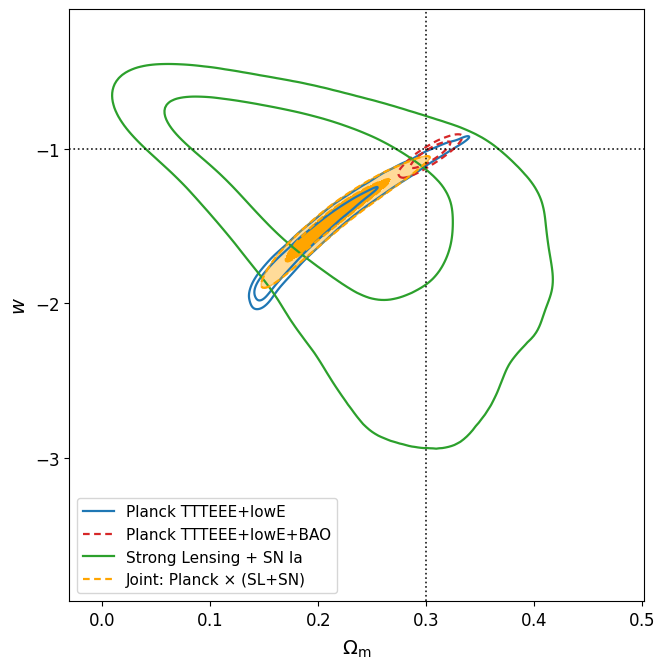

In [ ]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------------- Planck roots (wCDM) ----------------
planck_base_dir   = "/home/geng/Codes/lensing_cosmo/jax01/data"
planck_base_label = "base_w"  # 如需改成别的（例如 base_w_wa），改这里

root_nobao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE"
#     f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE"
)
root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO"
    # f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
# 若需 CMB lensing，把上面两个 root 改成 *_post_lensing 版本

# ---------------- 本地链设置 ----------------
base_dir = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
# local_pairs = [("linear", "Tri"), ("linear", "0.22")]  
local_pairs = [("linear", "0.22")]  
local_col_order = ('omegam', 'w')  # 若本地链顺序为 (w, Ωm) 则改为 ('w','omegam')

# ---------------- 工具函数 ----------------
def ensure_omegam_and_w(samples):
    """确保 Planck 样本里有 omegam 与 w（若 w0 存在则派生 w），并设置合适标签（GetDist 标签不要加 $）"""
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    # w
    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        elif hasattr(P, 'w'):
            pass
        else:
            raise RuntimeError("此 Planck 链未包含 w/w0；请改用 base_w 类链或相应 root。")

    # Ωm
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_{\rm m}')

    try: samples.setLabel('omegam', r'\Omega_{\rm m}')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w')):
    """
    将本地 numpy 链转为 MCSamples。
    order 指定列的物理含义与输出顺序（'omegam'/'w' 的排列）。
    """
    # 展平并去掉 burn-in
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
        ndim = flat.shape[-1]

    if set(order) != {'omegam','w'} or len(order) != 2:
        raise ValueError("order 必须是 ('omegam','w') 或 ('w','omegam')")

    # 如果实际列顺序与 order 不符，这里交换
    # 假设原始列为 [Ωm, w]；若 order=('w','omegam') 则交换：
    if order == ('w', 'omegam'):
        flat = flat[:, [1, 0]]

    # 用标准内部名字 + 无 $ 的标签
    names  = ['omegam', 'w']
    labels = [r'\Omega_{\rm m}', 'w']
    mcs = MCSamples(samples=flat, names=names, labels=labels)
    # 可选：再设置 chain 级别的显示名（用于图例）；由外部赋值更灵活
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    """汇总多组样本求统一坐标轴范围（分位数+边距）"""
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ======= 放在你的“画图前”工具区 =======
from scipy.stats import gaussian_kde

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    """从 MCSamples 中取两个参数组成 (N,2) 数组"""
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    """
    用 ref_pts(N,2) 的 KDE 在 base_mcs 的 (Ωm,w) 点上评估密度，作为附加权重，得到“联合后验”。
    假设两边对 (Ωm,w) 的先验一致或近似均匀；若先验不同，需要在这里做 prior 校正。
    """
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')     # (N,2)
    w_base   = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])

    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = kde(base_pts.T)                                        # p(theta | SL+SN)
    # 数值稳定化（只差一个归一化常数，不影响后验形状）
    dens = np.clip(dens, 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_pts,
        names=['omegam','w'],
        labels=[r'\Omega_{\rm m}','w'],
        weights=w_joint
    )
    joint.label = label
    return joint


# ---------------- 加载 Planck 链 ----------------
planck_nobao = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_nobao = ensure_omegam_and_w(planck_nobao)

planck_bao = loadMCSamples(root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_omegam_and_w(planck_bao)

# ---------------- 加载本地链（linear + Tri / 0.22） ----------------
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop2D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy_to_mcsamples(arr, burnin_frac=0.30, order=local_col_order)
    mcs.label = f"{evo} + {prior}"
    local_mcs.append(mcs)


# ======= 重要性重加权：Planck+BAO × (SL+SN) 得到“联合后验” =======
# --- 提取 SL+SN 的样本点 (Ωm,w) 作为 KDE 参考 ---
L = local_mcs[0]                              # 你现在 local_pairs 里只有一条：Strong Lensing + SN Ia
local_pts = extract_2col_from_mcs(L, 'omegam', 'w')

# --- 1) Joint: Planck (noBAO) × (SL+SN) ---
joint_planck = make_joint_by_kde(
    planck_nobao, local_pts,
    label=r'Joint: Planck × (SL+SN)',
    bw='scott'   # 可试 'silverman' 或数值带宽
)

# --- 2) Joint: Planck+BAO × (SL+SN) ---
joint_planck_bao = make_joint_by_kde(
    planck_bao, local_pts,
    label=r'Joint: Planck+BAO × (SL+SN)',
    bw='scott'
)


# （可选）等效重采样，得到等权样本用于导出/再处理：
# joint_eq = joint.resample_chain(nsamp=planck_pts.shape[0], seed=1234)


# ---------------- 画 Ωm – w：先画外轮廓，再叠加联合后验的填充 ----------------
# all_samples = [planck_nobao, planck_bao] + local_mcs + [joint_planck, joint_planck_bao]
all_samples = [planck_nobao, planck_bao] + local_mcs + [joint_planck]
legend_labels = [
    r'Planck TTTEEE+lowE',
    r'Planck TTTEEE+lowE+BAO',
    r'Strong Lensing + SN Ia',
    r'Joint: Planck × (SL+SN)',
    # r'Joint: Planck+BAO × (SL+SN)',
]

colors = ['#1f77b4', '#d62728', '#2ca02c', 'orange', '#8c564b']  # 蓝/红/绿/紫/棕
line_args = [
    {'ls': '-',  'lw': 1.6},   # Planck noBAO 轮廓
    {'ls': '--', 'lw': 1.6},   # Planck+BAO 轮廓
    {'ls': '-',  'lw': 1.6},   # SL+SN 轮廓
    {'ls': '--',  'lw': 1.6},   # 联合(Planck) 的“线框”用于图例
    # {'ls': '-',  'lw': 1.6},   # 联合(Planck+BAO) 的“线框”用于图例
]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

# 先画五条外轮廓（用于统一 legend 和坐标范围）
g.plot_2d(
    all_samples,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)

# # 再把两条“联合”以填充形式叠加，视觉更清晰（不再创建 legend 代理）
g.plot_2d(joint_planck,      ['omegam','w'], filled=True, colors=[colors[3]], add_legend_proxy=False, alpha=0.3)
# g.plot_2d(joint_planck_bao,  ['omegam','w'], filled=True, colors=[colors[4]], add_legend_proxy=False, alpha=0.3)

# 坐标范围（自动聚合所有样本的分位数）
ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w')      or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax.set_ylabel(r'$w$')

g.add_legend(legend_labels,
             legend_loc='lower left', colored_text=False)

# 参考线
ax.axvline(0.3,  color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)

out = "combined_omegam_w_planck_vs_local_with_joint.png"
g.export(out)
# print(f"Saved: {out}")


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
Removed no burn in
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
Removed no burn in
Removed no burn in

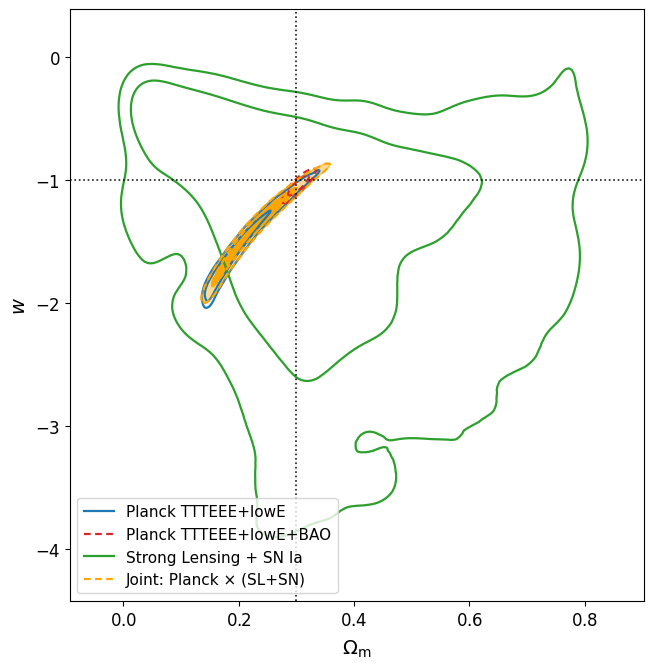

In [76]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------------- Planck roots (wCDM) ----------------
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w"  # 如需改成别的（例如 base_w_wa），改这里

root_nobao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE"
)
root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
# 若需 CMB lensing，把上面两个 root 改成 *_post_lensing 版本

# ---------------- 本地链设置 ----------------
base_dir = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
# local_pairs = [("linear", "Tri"), ("linear", "0.22")]  
evo_label = r"fullhier-ann"
prior_label = r"gaussian-hier-tri"
local_pairs    = [(f'{evo_label}', f'{prior_label}')]   # 本地 3D 链（含 omegam, w0, wa）
local_col_idx  = {'omegam': 0, 'w': 1}
local_col_order = ('omegam', 'w')  # 若本地链顺序为 (w, Ωm) 则改为 ('w','omegam')
burnin_frac    = 0.30

# ---------------- 工具函数 ----------------
def ensure_omegam_and_w(samples):
    """确保 Planck 样本里有 omegam 与 w（若 w0 存在则派生 w），并设置合适标签（GetDist 标签不要加 $）"""
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    # w
    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        elif hasattr(P, 'w'):
            pass
        else:
            raise RuntimeError("此 Planck 链未包含 w/w0；请改用 base_w 类链或相应 root。")

    # Ωm
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_{\rm m}')

    try: samples.setLabel('omegam', r'\Omega_{\rm m}')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w')):
    """
    将本地 numpy 链转为 MCSamples。
    order 指定列的物理含义与输出顺序（'omegam'/'w' 的排列）。
    """
    # 展平并去掉 burn-in
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
        ndim = flat.shape[-1]

    if set(order) != {'omegam','w'} or len(order) != 2:
        raise ValueError("order 必须是 ('omegam','w') 或 ('w','omegam')")

    # 如果实际列顺序与 order 不符，这里交换
    # 假设原始列为 [Ωm, w]；若 order=('w','omegam') 则交换：
    if order == ('w', 'omegam'):
        flat = flat[:, [1, 0]]

    # 用标准内部名字 + 无 $ 的标签
    names  = ['omegam', 'w']
    labels = [r'\Omega_{\rm m}', 'w']
    mcs = MCSamples(samples=flat, names=names, labels=labels)
    # 可选：再设置 chain 级别的显示名（用于图例）；由外部赋值更灵活
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    """汇总多组样本求统一坐标轴范围（分位数+边距）"""
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

from scipy.stats import gaussian_kde

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    """从 MCSamples 中取两个参数组成 (N,2) 数组"""
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    """
    用 ref_pts(N,2) 的 KDE 在 base_mcs 的 (Ωm,w) 点上评估密度，作为附加权重，得到“联合后验”。
    假设两边对 (Ωm,w) 的先验一致或近似均匀；若先验不同，需要在这里做 prior 校正。
    """
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')     # (N,2)
    w_base   = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])

    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = kde(base_pts.T)                                        # p(theta | SL+SN)
    # 数值稳定化（只差一个归一化常数，不影响后验形状）
    dens = np.clip(dens, 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_pts,
        names=['omegam','w'],
        labels=[r'\Omega_{\rm m}','w'],
        weights=w_joint
    )
    joint.label = label
    return joint

def numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=0.3, col_idx=None, label=None):
    """
    从本地 (nwalk, nstep, ndim) 或 (N, ndim) 的数组取出 (omegam, w0) 两列为 MCSamples。
    """
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    i_om = col_idx['omegam']; i_w0 = col_idx['w']
    sub  = flat[:, [i_om, i_w0]]
    mcs = MCSamples(samples=sub, names=['omegam','w'], labels=[r'\Omega_m', r'w'])
    if label: mcs.label = label
    return mcs


# ---------------- 加载 Planck 链 ----------------
planck_nobao = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_nobao = ensure_omegam_and_w(planck_nobao)

planck_bao = loadMCSamples(root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_omegam_and_w(planck_bao)

# ---------------- 加载本地链（linear + Tri / 0.22） ----------------
# local_mcs = []
# for evo, prior in local_pairs:
#     f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop493D-{evo}-{prior}.npy")
#     if not os.path.isfile(f):
#         raise FileNotFoundError(f"找不到本地链文件: {f}")
#     arr = np.load(f)
#     mcs = numpy_to_mcsamples(arr, burnin_frac=0.30, order=local_col_order)
#     mcs.label = f"{evo} + {prior}"
#     local_mcs.append(mcs)

local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop493D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy3d_to_mcsamples_Om_w0(arr, burnin_frac=burnin_frac, col_idx=local_col_idx,
                                     label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]


# ======= 重要性重加权：Planck+BAO × (SL+SN) 得到“联合后验” =======
# --- 提取 SL+SN 的样本点 (Ωm,w) 作为 KDE 参考 ---
# L = local_mcs[0]                              # 你现在 local_pairs 里只有一条：Strong Lensing + SN Ia
local_pts = extract_2col_from_mcs(SL, 'omegam', 'w')

# --- 1) Joint: Planck (noBAO) × (SL+SN) ---
joint_planck = make_joint_by_kde(
    planck_nobao, local_pts,
    label=r'Joint: Planck × (SL+SN)',
    bw='scott'   # 可试 'silverman' 或数值带宽
)

# --- 2) Joint: Planck+BAO × (SL+SN) ---
joint_planck_bao = make_joint_by_kde(
    planck_bao, local_pts,
    label=r'Joint: Planck+BAO × (SL+SN)',
    bw='scott'
)


# （可选）等效重采样，得到等权样本用于导出/再处理：
# joint_eq = joint.resample_chain(nsamp=planck_pts.shape[0], seed=1234)


# ---------------- 画 Ωm – w：先画外轮廓，再叠加联合后验的填充 ----------------
# all_samples = [planck_nobao, planck_bao] + local_mcs + [joint_planck, joint_planck_bao]
all_samples = [planck_nobao, planck_bao] + local_mcs + [joint_planck]
legend_labels = [
    r'Planck TTTEEE+lowE',
    r'Planck TTTEEE+lowE+BAO',
    r'Strong Lensing + SN Ia',
    r'Joint: Planck × (SL+SN)',
    # r'Joint: Planck+BAO × (SL+SN)',
]

colors = ['#1f77b4', '#d62728', '#2ca02c', 'orange', '#8c564b']  # 蓝/红/绿/紫/棕
line_args = [
    {'ls': '-',  'lw': 1.6},   # Planck noBAO 轮廓
    {'ls': '--', 'lw': 1.6},   # Planck+BAO 轮廓
    {'ls': '-',  'lw': 1.6},   # SL+SN 轮廓
    {'ls': '--',  'lw': 1.6},   # 联合(Planck) 的“线框”用于图例
    # {'ls': '-',  'lw': 1.6},   # 联合(Planck+BAO) 的“线框”用于图例
]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

# 先画五条外轮廓（用于统一 legend 和坐标范围）
g.plot_2d(
    all_samples,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)

# # 再把两条“联合”以填充形式叠加，视觉更清晰（不再创建 legend 代理）
g.plot_2d(joint_planck,      ['omegam','w'], filled=True, colors=[colors[3]], add_legend_proxy=False, alpha=0.3)
# g.plot_2d(joint_planck_bao,  ['omegam','w'], filled=True, colors=[colors[4]], add_legend_proxy=False, alpha=0.3)

# 坐标范围（自动聚合所有样本的分位数）
ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w')      or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax.set_ylabel(r'$w$')

g.add_legend(legend_labels,
             legend_loc='lower left', colored_text=False)

# 参考线
ax.axvline(0.3,  color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)

out = "combined_omegam_w_planck_vs_local_with_joint_hier.png"
g.export(out)
# print(f"Saved: {out}")


Columns: ('weight', 'minuslogpost', 'w', 'hrdrag', 'omm', 'As', 'omch2', 'omegam', 'omegamh2', 'omegal', 'zrei', 'YHe') ... total: 25
Removed no burn in


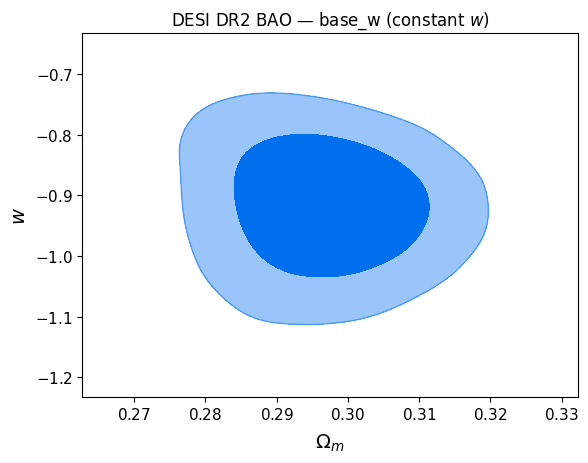

In [59]:
# pip install getdist matplotlib
import glob
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w/desi-bao-all"
files  = sorted(glob.glob(f"{folder}/chain.*.txt"))
if not files:
    raise FileNotFoundError("No chain.*.txt found under " + folder)

# Read each part; header starts with '#', names=True picks them up
parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
data  = np.concatenate(parts)  # structured array

names = data.dtype.names
print("Columns:", names[:12], "... total:", len(names))

def getcol(a, *candidates):
    for name in candidates:
        if name in a.dtype.names:
            return a[name]
    return None

# ---- parameters
w = getcol(data, "w", "w0")
if w is None:
    raise KeyError("Could not find 'w' (or 'w0') in columns.")

omegam = getcol(data, "omegam", "omm", "Omega_m", "OmegaM", "Om")
if omegam is None:
    # build Ωm from physical densities
    obh2 = getcol(data, "ombh2", "omega_b", "Omega_b_h2", "Obh2")
    och2 = getcol(data, "omch2", "omega_cdm", "Omega_c_h2", "Och2")
    h    = getcol(data, "h")
    if h is None:
        H0 = getcol(data, "H0")
        if H0 is None:
            raise KeyError("Need 'h' or 'H0' to construct Ωm.")
        h = H0/100.0
    if (obh2 is None) or (och2 is None):
        raise KeyError("Need 'ombh2' and 'omch2' to construct Ωm.")
    omegam = (obh2 + och2) / (h**2)

# ---- GetDist samples & plot
samples = np.vstack([omegam, w]).T

gd = MCSamples(samples=samples,
               names=["omegam","w"],
               labels=[r"\Omega_m", r"w"])   # <-- no $ here
gd.updateSettings({'ignore_rows': 0.0})

g = plots.get_single_plotter()
g.plot_2d(gd, "omegam", "w", filled=True)
plt.title("DESI DR2 BAO — base_w (constant $w$)")
plt.show()



/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Saved plot: wcdm_omegam_w_SL_planck_bao.png


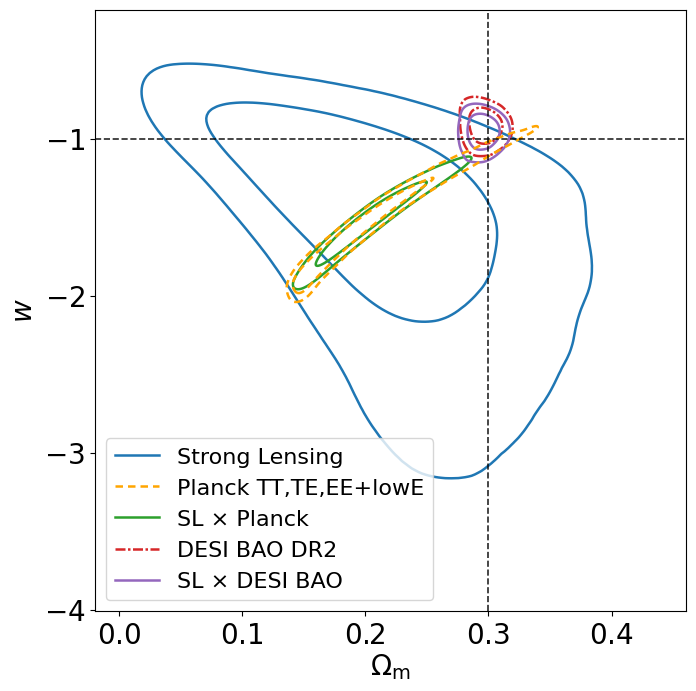

In [68]:
# === (1) 画图：5 组 (Omega_m, w) 不填充等高线：SL, Planck, SL+Planck, BAO, SL+BAO ===
# pip install getdist matplotlib scipy
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ---------------- Planck roots (wCDM) ----------------
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w"
root_nobao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE"
)

# ---------------- 本地链设置（SL+SN） ----------------
base_dir = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs = [("linear", "Tri")]
local_col_order = ('omegam', 'w')  # 若本地链顺序为 (w, Ωm) 则改 ('w','omegam')

# ---------------- 基础工具 ----------------
def ensure_omegam_and_w(samples):
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()
    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        elif hasattr(P, 'w'):
            pass
        else:
            raise RuntimeError("Planck 链未包含 w/w0；请改用 base_w 类链或相应 root。")
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_{\rm m}')
    try: samples.setLabel('omegam', r'\Omega_{\rm m}')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w'), label=None):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    if set(order) != {'omegam','w'} or len(order) != 2:
        raise ValueError("order 必须是 ('omegam','w') 或 ('w','omegam')")
    if order == ('w','omegam'):
        flat = flat[:, [1,0]]
    mcs = MCSamples(samples=flat, names=['omegam','w'], labels=[r'\Omega_{\rm m}', 'w'])
    if label: mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals: return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:,0]), np.max(vals[:,1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

# ---------------- DESI BAO (wCDM) 读取 ----------------
def _getcol(a, *cands):
    for name in cands:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_w(folder, label=r"DESI BAO (base_w)"):
    files  = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)
    w = _getcol(data, "w", "w0")
    if w is None:
        raise KeyError("DESI: missing 'w' (or 'w0').")
    omegam = _getcol(data, "omegam", "omm", "Omega_m", "OmegaM", "Om")
    if omegam is None:
        obh2 = _getcol(data, "ombh2", "omega_b", "Omega_b_h2", "Obh2")
        och2 = _getcol(data, "omch2", "omega_cdm", "Omega_c_h2", "Och2")
        h    = _getcol(data, "h")
        if h is None:
            H0 = _getcol(data, "H0")
            if H0 is None:
                raise KeyError("DESI: need 'h' or 'H0' to construct Ωm.")
            h = H0/100.0
        if (obh2 is None) or (och2 is None):
            raise KeyError("DESI: need 'ombh2' and 'omch2' to construct Ωm.")
        omegam = (obh2 + och2)/h**2
    weights = _getcol(data, "weight", "weights", "Weight", "Weights")
    gd = MCSamples(samples=np.vstack([omegam, w]).T,
                   names=["omegam","w"], labels=[r"\Omega_{\rm m}","w"],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

# ---------------- KDE 重要性重加权：联合后验 ----------------
def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')
    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])
    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = np.clip(kde(base_pts.T), 1e-300, None)
    w_joint = w_base * dens
    joint = MCSamples(samples=base_pts,
                      names=['omegam','w'],
                      labels=[r'\Omega_{\rm m}','w'],
                      weights=w_joint)
    joint.label = label
    return joint

# ---------------- 加载数据 ----------------
# Planck
planck = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck = ensure_omegam_and_w(planck)
planck.label = r'Planck TT,TE,EE+lowE'

# SL
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop2D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy_to_mcsamples(arr, burnin_frac=0.30, order=local_col_order, label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]

# DESI BAO
desi_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w/desi-bao-all"
BAO = load_desi_bao_w(desi_folder, label=r"DESI BAO DR2")

# ---------------- 联合：SL+Planck, SL+BAO ----------------
SL_pts = extract_2col_from_mcs(SL, 'omegam', 'w')
SLxPlanck = make_joint_by_kde(planck, SL_pts, label=r"SL × Planck")
SLxBAO    = make_joint_by_kde(BAO,    SL_pts, label=r"SL × DESI BAO")

# ---------------- 画 5 组不填充等高线：SL, Planck, SL+Planck, BAO, SL+BAO ----------------
to_plot = [SL, planck, SLxPlanck, BAO, SLxBAO]
legend_labels = [s.label for s in to_plot]

COL_SL      = '#1f77b4'  # 蓝 实线
COL_PLK     = 'orange'   # 橙 虚线 --
COL_SLPLK   = '#2ca02c'  # 绿 实线
COL_BAO     = '#d62728'  # 红（-.）
COL_SLBAO   = '#9467bd'  # 紫 实线

colors =   [COL_SL,  COL_PLK,  COL_SLPLK, COL_BAO,  COL_SLBAO]
line_args =[
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '--', 'lw': 1.8, 'zorder':5},   # Planck
    {'ls': '-',  'lw': 1.8},   # SL+Planck
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL+BAO
]

g = plots.get_subplot_plotter(width_inch=7.0)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

g.plot_2d(
    to_plot,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(to_plot, 'w')      or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$',fontsize=20)
ax.set_ylabel(r'$w$',fontsize=20)

# 参考虚线：Omega_m=0.3, w=-1
ax.axvline(0.3,  ls='--', lw=1.2, color='k', alpha=0.85, zorder=5)
ax.axhline(-1.,  ls='--', lw=1.2, color='k', alpha=0.85, zorder=5)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False)

out = "wcdm_omegam_w_SL_planck_bao.png"
g.export(out)
print(f"Saved plot: {out}")


In [70]:
# === (2) 一维统计量：mean/sigma、median/MAD、peak/q16/q84（含相对 peak 的不对称误差）===
import numpy as np
from scipy.stats import gaussian_kde

def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    grid = np.linspace(np.min(x), np.max(x), grids)
    kde  = gaussian_kde(x, weights=w) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return grid[np.argmax(dens)]

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.mean(x), np.std(x, ddof=0)
    wn = _normalize_weights(w)
    mu = np.sum(wn * x)
    sig = np.sqrt(np.sum(wn * (x - mu)**2))
    return mu, sig

def _get_param_array(mcs, name):
    P = mcs.getParams()
    return np.asarray(getattr(P, name), float)

def summarize_mcs_1dset(mcs, names=('omegam','w')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array(mcs, nm)
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ[nm]
        peak_txt   = f"peak = {s['peak']:.6f} "
        median_txt = f"median = {s['median']:.6f} (q16={s['q16']:.6f}, q84={s['q84']:.6f};  Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) (MAD={s['mad']:.6f})"
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---- 按 5 组输出（需与上一个代码块中的对象名一致）----
stats_targets = [
    (SL.label,       SL),        # 1) SL
    (planck.label,   planck),    # 2) Planck
    (SLxPlanck.label, SLxPlanck),# 3) SL+Planck
    (BAO.label,      BAO),       # 4) BAO
    (SLxBAO.label,   SLxBAO),    # 5) SL+BAO
]
for tag, mcs in stats_targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w'))
    print_summary_1d(tag, s, names=('omegam','w'))



=== Strong Lensing ===
omegam : peak = 0.210565  | median = 0.210062 (q16=0.140494, q84=0.281520;  Δ-=0.069568, Δ+=0.071458) (MAD=0.069781) | mean = 0.211179, sigma = 0.071910
w      : peak = -1.281820  | median = -1.423670 (q16=-2.008127, q84=-1.026818;  Δ-=0.584457, Δ+=0.396852) (MAD=0.472678) | mean = -1.522642, sigma = 0.545959

=== Planck TT,TE,EE+lowE ===
omegam : peak = 0.155202  | median = 0.184396 (q16=0.153777, q84=0.243869;  Δ-=0.030619, Δ+=0.059473) (MAD=0.041114) | mean = 0.197653, sigma = 0.047638
w      : peak = -1.788563  | median = -1.631162 (q16=-1.856842, q84=-1.298890;  Δ-=0.225681, Δ+=0.332272) (MAD=0.280285) | mean = -1.584911, sigma = 0.265049

=== SL × Planck ===
omegam : peak = 0.201535  | median = 0.202127 (q16=0.173241, q84=0.233976;  Δ-=0.028886, Δ+=0.031849) (MAD=0.030722) | mean = 0.204086, sigma = 0.030612
w      : peak = -1.516262  | median = -1.521702 (q16=-1.709035, q84=-1.343487;  Δ-=0.187333, Δ+=0.178215) (MAD=0.185542) | mean = -1.523886, sigma = 0

/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Saved plot: wcdm_omegam_w_SL_planck_bao.png


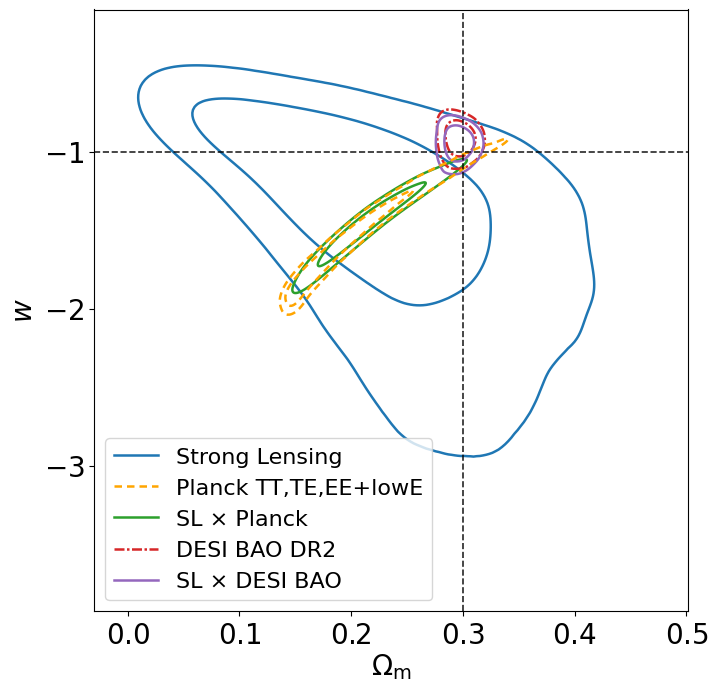

In [71]:
# === (1) 画图：5 组 (Omega_m, w) 不填充等高线：SL, Planck, SL+Planck, BAO, SL+BAO ===
# pip install getdist matplotlib scipy
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ---------------- Planck roots (wCDM) ----------------
planck_base_dir   = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data"
planck_base_label = "base_w"
root_nobao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE",
    f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE"
)

# ---------------- 本地链设置（SL+SN） ----------------
base_dir = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
local_pairs = [("linear", "0.22")]
local_col_order = ('omegam', 'w')  # 若本地链顺序为 (w, Ωm) 则改 ('w','omegam')

# ---------------- 基础工具 ----------------
def ensure_omegam_and_w(samples):
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()
    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        elif hasattr(P, 'w'):
            pass
        else:
            raise RuntimeError("Planck 链未包含 w/w0；请改用 base_w 类链或相应 root。")
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_{\rm m}')
    try: samples.setLabel('omegam', r'\Omega_{\rm m}')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w'), label=None):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
    if set(order) != {'omegam','w'} or len(order) != 2:
        raise ValueError("order 必须是 ('omegam','w') 或 ('w','omegam')")
    if order == ('w','omegam'):
        flat = flat[:, [1,0]]
    mcs = MCSamples(samples=flat, names=['omegam','w'], labels=[r'\Omega_{\rm m}', 'w'])
    if label: mcs.label = label
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals: return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:,0]), np.max(vals[:,1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

# ---------------- DESI BAO (wCDM) 读取 ----------------
def _getcol(a, *cands):
    for name in cands:
        if name in a.dtype.names:
            return a[name]
    return None

def load_desi_bao_w(folder, label=r"DESI BAO (base_w)"):
    files  = sorted(glob.glob(os.path.join(folder, "chain.*.txt")))
    if not files:
        raise FileNotFoundError("No chain.*.txt found under " + folder)
    parts = [np.genfromtxt(f, names=True, comments="#") for f in files]
    data  = np.concatenate(parts)
    w = _getcol(data, "w", "w0")
    if w is None:
        raise KeyError("DESI: missing 'w' (or 'w0').")
    omegam = _getcol(data, "omegam", "omm", "Omega_m", "OmegaM", "Om")
    if omegam is None:
        obh2 = _getcol(data, "ombh2", "omega_b", "Omega_b_h2", "Obh2")
        och2 = _getcol(data, "omch2", "omega_cdm", "Omega_c_h2", "Och2")
        h    = _getcol(data, "h")
        if h is None:
            H0 = _getcol(data, "H0")
            if H0 is None:
                raise KeyError("DESI: need 'h' or 'H0' to construct Ωm.")
            h = H0/100.0
        if (obh2 is None) or (och2 is None):
            raise KeyError("DESI: need 'ombh2' and 'omch2' to construct Ωm.")
        omegam = (obh2 + och2)/h**2
    weights = _getcol(data, "weight", "weights", "Weight", "Weights")
    gd = MCSamples(samples=np.vstack([omegam, w]).T,
                   names=["omegam","w"], labels=[r"\Omega_{\rm m}","w"],
                   weights=weights if weights is not None else None)
    gd.updateSettings({'ignore_rows': 0.0})
    gd.label = label
    return gd

# ---------------- KDE 重要性重加权：联合后验 ----------------
def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')
    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])
    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = np.clip(kde(base_pts.T), 1e-300, None)
    w_joint = w_base * dens
    joint = MCSamples(samples=base_pts,
                      names=['omegam','w'],
                      labels=[r'\Omega_{\rm m}','w'],
                      weights=w_joint)
    joint.label = label
    return joint

# ---------------- 加载数据 ----------------
# Planck
planck = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck = ensure_omegam_and_w(planck)
planck.label = r'Planck TT,TE,EE+lowE'

# SL
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop2D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy_to_mcsamples(arr, burnin_frac=0.30, order=local_col_order, label=r"Strong Lensing")
    local_mcs.append(mcs)
SL = local_mcs[0]

# DESI BAO
desi_folder = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/DESI_BAO_base_w/desi-bao-all"
BAO = load_desi_bao_w(desi_folder, label=r"DESI BAO DR2")

# ---------------- 联合：SL+Planck, SL+BAO ----------------
SL_pts = extract_2col_from_mcs(SL, 'omegam', 'w')
SLxPlanck = make_joint_by_kde(planck, SL_pts, label=r"SL × Planck")
SLxBAO    = make_joint_by_kde(BAO,    SL_pts, label=r"SL × DESI BAO")

# ---------------- 画 5 组不填充等高线：SL, Planck, SL+Planck, BAO, SL+BAO ----------------
to_plot = [SL, planck, SLxPlanck, BAO, SLxBAO]
legend_labels = [s.label for s in to_plot]

COL_SL      = '#1f77b4'  # 蓝 实线
COL_PLK     = 'orange'   # 橙 虚线 --
COL_SLPLK   = '#2ca02c'  # 绿 实线
COL_BAO     = '#d62728'  # 红（-.）
COL_SLBAO   = '#9467bd'  # 紫 实线

colors =   [COL_SL,  COL_PLK,  COL_SLPLK, COL_BAO,  COL_SLBAO]
line_args =[
    {'ls': '-',  'lw': 1.8},   # SL
    {'ls': '--', 'lw': 1.8, 'zorder':5},   # Planck
    {'ls': '-',  'lw': 1.8},   # SL+Planck
    {'ls': '-.', 'lw': 1.8},   # BAO
    {'ls': '-',  'lw': 1.8},   # SL+BAO
]

g = plots.get_subplot_plotter(width_inch=7.0)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

g.plot_2d(
    to_plot,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=None,
)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(to_plot, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(to_plot, 'w')      or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$',fontsize=20)
ax.set_ylabel(r'$w$',fontsize=20)

# 参考虚线：Omega_m=0.3, w=-1
ax.axvline(0.3,  ls='--', lw=1.2, color='k', alpha=0.85, zorder=5)
ax.axhline(-1.,  ls='--', lw=1.2, color='k', alpha=0.85, zorder=5)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False)

out = "wcdm_omegam_w_SL_planck_bao.png"
g.export(out)
print(f"Saved plot: {out}")


In [ ]:
# === (2) 一维统计量：mean/sigma、median/MAD、peak/q16/q84（含相对 peak 的不对称误差）===
import numpy as np
from scipy.stats import gaussian_kde

def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    grid = np.linspace(np.min(x), np.max(x), grids)
    kde  = gaussian_kde(x, weights=w) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return grid[np.argmax(dens)]

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.mean(x), np.std(x, ddof=0)
    wn = _normalize_weights(w)
    mu = np.sum(wn * x)
    sig = np.sqrt(np.sum(wn * (x - mu)**2))
    return mu, sig

def _get_param_array(mcs, name):
    P = mcs.getParams()
    return np.asarray(getattr(P, name), float)

def summarize_mcs_1dset(mcs, names=('omegam','w')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array(mcs, nm)
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ[nm]
        peak_txt   = f"peak = {s['peak']:.6f} "
        median_txt = f"median = {s['median']:.6f} (q16={s['q16']:.6f}, q84={s['q84']:.6f};  Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) (MAD={s['mad']:.6f})"
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---- 按 5 组输出（需与上一个代码块中的对象名一致）----
stats_targets = [
    (SL.label,       SL),        # 1) SL
    (planck.label,   planck),    # 2) Planck
    (SLxPlanck.label, SLxPlanck),# 3) SL+Planck
    # (BAO.label,      BAO),       # 4) BAO
    # (SLxBAO.label,   SLxBAO),    # 5) SL+BAO
]
for tag, mcs in stats_targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w'))
    print_summary_1d(tag, s, names=('omegam','w'))



=== Strong Lensing ===
omegam : peak = 0.235386  | median = 0.219464 (q16=0.138134, q84=0.299148;  Δ-=0.081330, Δ+=0.079684) (MAD=0.079570) | mean = 0.219832, sigma = 0.081016
w      : peak = -1.216905  | median = -1.298772 (q16=-1.844373, q84=-0.913351;  Δ-=0.545601, Δ+=0.385421) (MAD=0.446562) | mean = -1.391399, sigma = 0.524042

=== Planck TT,TE,EE+lowE ===
omegam : peak = 0.155202  | median = 0.184396 (q16=0.153777, q84=0.243869;  Δ-=0.030619, Δ+=0.059473) (MAD=0.041114) | mean = 0.197653, sigma = 0.047638
w      : peak = -1.788563  | median = -1.631162 (q16=-1.856842, q84=-1.298890;  Δ-=0.225681, Δ+=0.332272) (MAD=0.280285) | mean = -1.584911, sigma = 0.265049

=== SL × Planck ===
omegam : peak = 0.210508  | median = 0.214153 (q16=0.183767, q84=0.249371;  Δ-=0.030386, Δ+=0.035217) (MAD=0.032512) | mean = 0.216509, sigma = 0.032609
w      : peak = -1.410123  | median = -1.449270 (q16=-1.634640, q84=-1.275065;  Δ-=0.185370, Δ+=0.174205) (MAD=0.182441) | mean = -1.453313, sigma = 0

识别到列： cosmological_parameters--omega_m cosmological_parameters--w
Removed no burn in


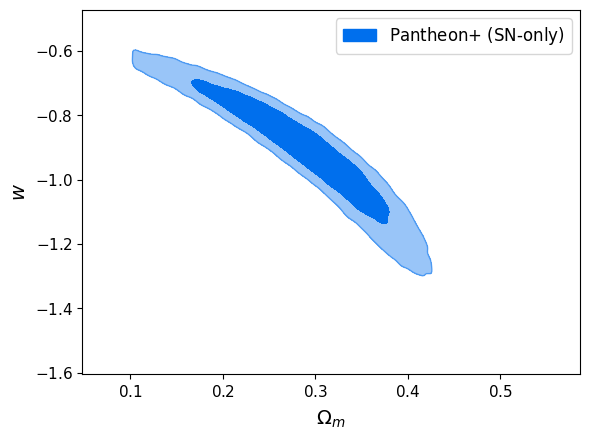

In [5]:


# pip install getdist pandas matplotlib
import re, os
import pandas as pd
import numpy as np
from getdist import plots, MCSamples
import matplotlib.pyplot as plt

chain_path = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/Pantheon+only_FlatwCDM.txt"  # ← 改成你的路径

def read_cosmosis_chain_with_commented_header(path):
    """
    读取像你提供的这种 CosmoSIS 文本链：
    第一行是被 # 注释的表头（以制表/空白分隔），后面是数据行。
    返回：DataFrame（带列名）
    """
    header_names = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            # 典型第一行格式：
            # #cosmological_parameters--omega_m  cosmological_parameters--h0  cosmological_parameters--w  ...
            if line.startswith("#") and "--" in line:
                # 去掉开头的 # ，按任意空白分隔
                header_names = re.split(r"\s+", line.lstrip("#").strip())
                break
    if header_names is None:
        raise RuntimeError("未在注释中找到表头，请检查链文件。")

    # 用解析出的列名读数据；跳过其它注释行
    df = pd.read_csv(path, sep=r"\s+", header=None, names=header_names,
                     comment="#", engine="python")
    return df

def find_cols(df):
    # 你的文件中就是这些名字：
    # 'cosmological_parameters--omega_m', 'cosmological_parameters--w'
    # 为了稳健，做一下模糊匹配
    def pick(pats):
        for c in df.columns:
            for p in pats:
                if re.fullmatch(p, c, flags=re.I):
                    return c
        return None

    om_col = pick([r".*--omega_m$", r"omega_m$", r".*\bomeg[a]?_?m\b"])
    w_col  = pick([r".*--w$", r".*--w0$", r"(?:^|.*\b)w0?$"])
    if om_col is None or w_col is None:
        raise RuntimeError(f"找不到 Ω_m 或 w 列。现有列名：{list(df.columns)}")
    return om_col, w_col

def plot_omegam_w_from_df(df, om_col, w_col, label=r"Pantheon$+$ (SN-only)"):
    # emcee 链已经是后验样本，通常无需额外权重
    samples = MCSamples(
        samples=np.vstack([df[om_col].to_numpy(), df[w_col].to_numpy()]).T,
        names=["omegam","w"],
        labels=[r"\Omega_m", r"w"]
    )
    g = plots.get_single_plotter()
    g.plot_2d(samples, "omegam", "w", filled=True)
    g.add_legend([label], legend_loc="upper right")
    # 需要的话可以设置范围，比如：
    # g.set_axes_limits([0.15, 0.5], [-1.6, -0.4])
    plt.show()

# --- 一键执行 ---
df = read_cosmosis_chain_with_commented_header(chain_path)
om_col, w_col = find_cols(df)
print("识别到列：", om_col, w_col)
plot_omegam_w_from_df(df, om_col, w_col)


Removed no burn in
Removed no burn in
Removed no burn in


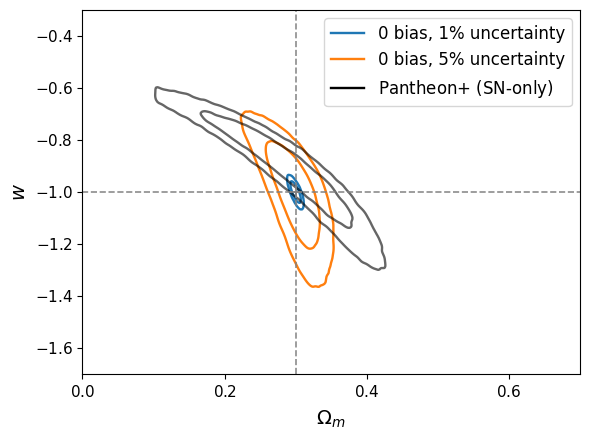

In [43]:
# pip install getdist pandas matplotlib
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# ============= 读 Pantheon+（CosmoSIS 风格文本链） =============
def read_cosmosis_chain_with_commented_header(path):
    header_names = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("#") and "--" in line:
                header_names = re.split(r"\s+", line.lstrip("#").strip())
                break
    if header_names is None:
        raise RuntimeError("未在注释中找到表头，请检查链文件。")
    df = pd.read_csv(path, sep=r"\s+", header=None, names=header_names,
                     comment="#", engine="python")
    return df

def find_cols(df):
    def pick(pats):
        for c in df.columns:
            for p in pats:
                if re.fullmatch(p, c, flags=re.I):
                    return c
        return None
    om_col = pick([r".*--omega_m$", r"omega_m$", r".*\bomeg[a]?_?m\b"])
    w_col  = pick([r".*--w$", r".*--w0$", r"(?:^|.*\b)w0?$"])
    if om_col is None or w_col is None:
        raise RuntimeError(f"找不到 Ω_m 或 w 列。现有列名：\n{list(df.columns)}")
    return om_col, w_col

def make_snia_samples(chain_path, label=r"Pantheon$+$ (SN-only)"):
    df = read_cosmosis_chain_with_commented_header(chain_path)
    om_col, w_col = find_cols(df)
    samples = np.vstack([df[om_col].to_numpy(), df[w_col].to_numpy()]).T
    return MCSamples(samples=samples, names=["omegam","w"], labels=[r"\Omega_m", r"w"], label=label)

# ============= 读本地链（numpy 3D：nwalkers × nsteps × ndim） =============
def pretty_label(raw: str) -> str:
    """
    "0_bias_0.01" -> "0 bias, 1% uncertainty"
    其它不匹配：仅将下划线替空格。
    """
    s = str(raw).strip()
    m = re.fullmatch(r'\s*(-?\d+(?:\.\d+)?)_bias_(\d*\.?\d+)\s*', s)
    if m:
        bias = float(m.group(1))
        unc  = float(m.group(2))
        return f"{bias:g} bias, {unc*100:g}% uncertainty"
    return s.replace("_", " ")

def load_local_samples(base_dir, evo_labels, ndim_expected=2, names=("omegam","w"), labels=(r"\Omega_m", r"w")):
    """
    读取 base_dir/Output/{evo}_chain_kept.npy；假定最后维顺序是 [Ωm, w]（若不是请调整 names/labels 及取列方式）。
    返回：[(MCSamples, legend_label, color_index), ...]
    """
    results = []
    for k, evo in enumerate(evo_labels):
        folder = os.path.join(base_dir, "Output")
        fname  = os.path.join(folder, f"{evo}_chain_kept.npy")
        if not os.path.isfile(fname):
            raise FileNotFoundError(f"Missing samples file: {fname}")
        arr = np.load(fname)  # (nwalkers, nsteps, ndim)
        if arr.ndim != 3 or arr.shape[-1] != ndim_expected:
            raise ValueError(f"{fname} shape {arr.shape}, 期望 (*, *, {ndim_expected}).")
        flat = arr.reshape(-1, arr.shape[-1])  # (N, ndim)
        label = pretty_label(str(evo))
        mcs = MCSamples(samples=flat, names=list(names), labels=list(labels), label=label)
        results.append(mcs)
    return results

# ============= 画 Ωm–w 单张图 =============
def plot_omegam_w_overlay(
    base_dir,
    evo_labels,
    chain_path_snia,
    colors=None,
    filled_lens=False,
    filled_snia=True,
    legend_loc="upper right",
    ref_guides=True,
    omega_m_ref=0.3,
    w_ref=-1.0,
    ref_style=None,
    xlim=None, ylim=None,
    dpi=220,
    outpath=None
):
    # 读取样本
    lens_samples = load_local_samples(base_dir, evo_labels)   # 多条
    sn_samples   = make_snia_samples(chain_path_snia)         # 单条

    # 颜色
    if colors is None:
        # 默认给本地链一组循环色，SN 用最后一个对比色
        base_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', []) or [f"C{i}" for i in range(10)]
        colors = [base_cycle[i % len(base_cycle)] for i in range(len(lens_samples))] + [base_cycle[-1]]
    elif len(colors) < len(lens_samples) + 1:
        # 不足则循环补齐
        base_cycle = (colors or []) + (plt.rcParams['axes.prop_cycle'].by_key().get('color', []) or [f"C{i}" for i in range(10)])
        colors = [base_cycle[i % len(base_cycle)] for i in range(len(lens_samples) + 1)]

    # 绘图
    g = plots.get_single_plotter(width_inch=6)
    # 先画本地链（空心/线框）
    g.plot_2d(lens_samples, "omegam", "w",
              filled=filled_lens,
              colors=colors[:len(lens_samples)])
    
    # 再叠加 SNIa：不要传 colors=...，也不要传 filled=
    g.add_2d_contours(sn_samples, "omegam", "w",
                      cols=[colors[-1]],   # 这里指定颜色
                      alpha=0.6)           # 透明度可选



    # 参考线
    if ref_guides:
        style = dict(color="gray", ls="--", lw=1.2, alpha=0.9)
        if isinstance(ref_style, dict):
            style.update(ref_style)
        ax = plt.gca()
        ax.axvline(omega_m_ref, **style)
        ax.axhline(w_ref, **style)
        ax.plot([omega_m_ref], [w_ref], marker="+", ms=9, mew=1.4, color=style["color"], alpha=style["alpha"])

    # 范围
    if xlim: g.set_xlim(xlim[0], xlim[1])
    if ylim: g.set_ylim(ylim[0], ylim[1])

    # 图例（顺序：本地链各条 + SNIa）
    legend_labels = [m.label for m in lens_samples] + [sn_samples.label]
    # getdist 自带 add_legend 会从 axes 里抓色和线型
    g.add_legend(legend_labels, legend_loc=legend_loc)
    plt.gca().set_xlim(0.0, 0.7)
    plt.gca().set_ylim(-1.7, -0.3)

    # 导出
    if outpath:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()

# ================= 使用示例 =================
if __name__ == "__main__":
    base_dir  = r"/home/astrodust/SG/sgl_cosmo/codes"  # ← 改成你的
    evo_list  = ["0_bias_0.01","0_bias_0.05"]  # ← 你的本地链名
    chain_path = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/Pantheon+only_FlatwCDM.txt"  # ← 改成你的 Pantheon+ 链路径

    plot_omegam_w_overlay(
        base_dir=base_dir,
        evo_labels=evo_list,
        chain_path_snia=chain_path,
        filled_lens=False,       # 本地链空心线
        filled_snia=True,        # SNIa 填充
        legend_loc="upper right",
        ref_guides=True,
        omega_m_ref=0.3,
        w_ref=-1.0,
        xlim=None, ylim=None,
        outpath=os.path.join(base_dir, "Results", "omegam_w_lens_plus_SN.png")
    )


Removed no burn in
Removed no burn in
Removed no burn in


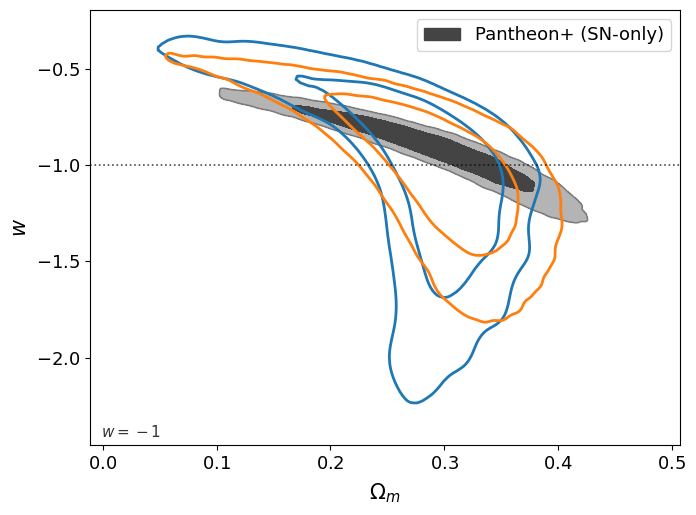

In [28]:
# pip install getdist pandas matplotlib
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# ---------- 工具：读取 Pantheon+ CosmoSIS 文本链（首行注释表头） ----------
def read_cosmosis_chain_with_commented_header(path):
    header_names = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("#") and "--" in line:
                header_names = re.split(r"\s+", line.lstrip("#").strip())
                break
    if header_names is None:
        raise RuntimeError("未在注释中找到表头，请检查链文件。")
    df = pd.read_csv(path, sep=r"\s+", header=None, names=header_names,
                     comment="#", engine="python")
    return df

def find_cols_omegam_w(df):
    def pick(pats):
        for c in df.columns:
            for p in pats:
                if re.fullmatch(p, c, flags=re.I):
                    return c
        return None
    om_col = pick([r".*--omega_m$", r"omega_m$", r".*\bomeg[a]?_?m\b"])
    w_col  = pick([r".*--w$", r".*--w0$", r"(?:^|.*\b)w0?$"])
    if om_col is None or w_col is None:
        raise RuntimeError(f"找不到 Ω_m 或 w 列。现有列名：{list(df.columns)}")
    return om_col, w_col

def mcs_from_pantheon_sn(path, label="Pantheon+ (SN-only)"):
    df = read_cosmosis_chain_with_commented_header(path)
    om_col, w_col = find_cols_omegam_w(df)
    arr2 = np.vstack([df[om_col].to_numpy(), df[w_col].to_numpy()]).T  # (N,2)
    mcs = MCSamples(samples=arr2, names=["omegam","w"],
                    labels=[r"\Omega_m", r"w"], label=label)
    return mcs, arr2

# ---------- 工具：读取 npy 链（支持 2D 或 3D），并扁平化 ----------
def flatten_chain(arr, burn_in_frac=0.0, thin=1):
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        i0 = int(nstep * burn_in_frac)
        flat = arr[:, i0::thin, :].reshape(-1, ndim)
    elif arr.ndim == 2:
        i0 = int(arr.shape[0] * burn_in_frac)
        flat = arr[i0::thin, :]
    else:
        raise ValueError(f"Unsupported arr.ndim={arr.ndim}")
    return flat

def mcs_from_local_2d_npy(npy_path, label, burn_in_frac=0.0, thin=1, om_index=0, w_index=1):
    if not os.path.isfile(npy_path):
        raise FileNotFoundError(npy_path)
    arr = np.load(npy_path)
    flat = flatten_chain(arr, burn_in_frac=burn_in_frac, thin=thin)
    if flat.shape[1] <= max(om_index, w_index):
        raise ValueError(f"{npy_path} 维度不足：shape={flat.shape}")
    arr2 = np.vstack([flat[:, om_index], flat[:, w_index]]).T  # (N,2)
    mcs = MCSamples(samples=arr2, names=["omegam","w"],
                    labels=[r"\Omega_m", r"w"], label=label)
    return mcs, arr2

# ---------- 稳健坐标范围 ----------
def robust_range(arr_list, q_lo=0.001, q_hi=0.999, pad_frac=0.05):
    """
    arr_list: 多个 (N,2) 数组
    返回 x_range, y_range，按分位数联合覆盖并加边距
    """
    xs = np.concatenate([a[:,0] for a in arr_list if a is not None])
    ys = np.concatenate([a[:,1] for a in arr_list if a is not None])
    x_lo, x_hi = np.quantile(xs, [q_lo, q_hi])
    y_lo, y_hi = np.quantile(ys, [q_lo, q_hi])
    # padding
    dx = max(1e-6, x_hi - x_lo)
    dy = max(1e-6, y_hi - y_lo)
    x_lo -= pad_frac * dx
    x_hi += pad_frac * dx
    y_lo -= pad_frac * dy
    y_hi += pad_frac * dy
    return [float(x_lo), float(x_hi)], [float(y_lo), float(y_hi)]

# ---------- 主函数：叠加三类结果到一张 Ωm–w 图 ----------
def plot_omegam_w_all(
    sn_chain_path,
    # 本地 2D 链（mcmc_cosmop2D-evo-prior.npy）
    local_base_dir=None,
    local_pairs=None,   # [("linear","noevodata+noevofit"), ...]；None 则跳过
    # kept 链（{evo}_chain_kept.npy）
    kept_base_dir=None,
    kept_evos=None,     # ["0_bias", "1_bias", ...]；None 则跳过
    # 抽样控制
    local_burn_in=0.0, local_thin=1,
    kept_burn_in=0.0, kept_thin=1,
    # 视觉
    colors_local=None, colors_kept=None,
    show_local_in_legend=False,
    w_ref_line=True,
    out_png=None
):
    # 1) Pantheon+（填充）
    m_sn, arr_sn = mcs_from_pantheon_sn(sn_chain_path, label="Pantheon+ (SN-only)")

    # 2) 本地 2D 链
    locals_mcs, locals_arr = [], []
    if local_pairs:
        for evo, prior in local_pairs:
            # 保持你当前硬编码的路径形式
            f2d = os.path.join(local_base_dir, "Output/linear-noevodata+noevofit",
                               f"mcmc_cosmop2D-{evo}-{prior}.npy")
            m, a = mcs_from_local_2d_npy(f2d, label=f"{evo}-{prior}",
                                         burn_in_frac=local_burn_in, thin=local_thin,
                                         om_index=0, w_index=1)
            locals_mcs.append(m)
            locals_arr.append(a)

    # 3) kept 链
    kept_mcs, kept_arr = [], []
    if kept_evos:
        for evo in kept_evos:
            fkp = os.path.join(kept_base_dir, "Output", f"{evo}_chain_kept.npy")
            m, a = mcs_from_local_2d_npy(fkp, label=f"{evo} (kept)",
                                         burn_in_frac=kept_burn_in, thin=kept_thin,
                                         om_index=0, w_index=1)
            kept_mcs.append(m)
            kept_arr.append(a)

    # 4) 作图
    g = plots.get_single_plotter(width_inch=7)
    g.settings.axes_labelsize = 15
    g.settings.axes_fontsize  = 13
    g.settings.legend_fontsize = 13

    # Pantheon+ 填充
    g.plot_2d(m_sn, "omegam", "w", filled=True, colors=["#444444"])

    # 颜色准备
    if colors_local is None and locals_mcs:
        base = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
        if not base:
            base = [f"C{i}" for i in range(10)]
        colors_local = [base[i % len(base)] for i in range(len(locals_mcs))]
    if colors_kept is None and kept_mcs:
        base = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
        start = len(locals_mcs) % len(base) if locals_mcs else 0
        colors_kept = [base[(start + i) % len(base)] for i in range(len(kept_mcs))]

    # 叠加本地（空心；不进 legend）
    for m, c in zip(locals_mcs, colors_local or []):
        g.plot_2d(m, "omegam", "w", filled=False, colors=[c], add_legend_proxy=False, alpha=1.0)

    # 叠加 kept（空心；不进 legend）
    for m, c in zip(kept_mcs, colors_kept or []):
        g.plot_2d(m, "omegam", "w", filled=False, colors=[c], add_legend_proxy=False, alpha=1.0)

    # —— 统一坐标范围：覆盖三类链的联合范围（稳健分位+边距） ——
    x_rng, y_rng = robust_range([arr_sn] + locals_arr + kept_arr,
                            q_lo=0.0005, q_hi=0.9995, pad_frac=0.10)
    
    ax = plt.gca()         # 取到当前 2D 子图轴
    ax.set_xlim(x_rng)     # 强制 x 范围
    ax.set_ylim(y_rng)     # 强制 y 范围


    # 仅加入 Pantheon+ 的图例
    g.add_legend(["Pantheon+ (SN-only)"], legend_loc="upper right")

    # 参考线 w = -1
    if w_ref_line:
        ax = plt.gca()
        ax.axhline(-1.0, ls=":", lw=1.2, color="k", alpha=0.7)
        ax.text(0.02, 0.02, r"$w=-1$", transform=ax.transAxes, fontsize=11, alpha=0.8)

    if out_png:
        os.makedirs(os.path.dirname(out_png), exist_ok=True)
        plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

# ================= 使用示例 =================
if __name__ == "__main__":
    # 1) Pantheon+（CosmoSIS 文本链）
    sn_chain_path = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/Pantheon+only_FlatwCDM.txt"

    # 2) 之前图中的本地 2D 链（可多个）
    local_base_dir = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
    local_pairs = [("linear", "noevodata+noevofit")]

    # 3) 新增 kept 链所在根目录与标签（可多个）
    kept_base_dir = r"/home/astrodust/SG/sgl_cosmo/codes"
    kept_evos = ["0_bias_0.1"]

    plot_omegam_w_all(
        sn_chain_path=sn_chain_path,
        local_base_dir=local_base_dir,
        local_pairs=local_pairs,
        kept_base_dir=kept_base_dir,
        kept_evos=kept_evos,
        local_burn_in=0.2, local_thin=5,
        kept_burn_in=0.0, kept_thin=1,
        show_local_in_legend=False,
        w_ref_line=True,
        out_png=os.path.join(local_base_dir, "Results", "compare_Om_w_SN_local_kept.png")
    )


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
Removed no burn in
Removed no burn in
Saved: combined_omegam_w_1sigma_2sigma_nofill.png


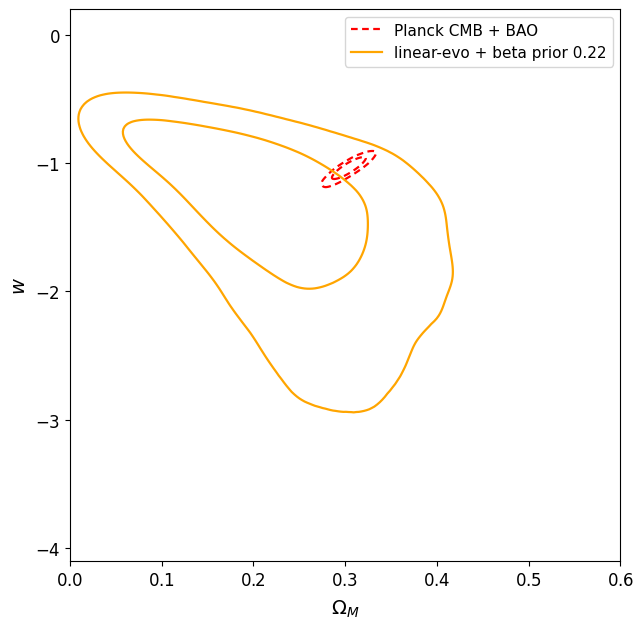

In [22]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------- Planck chain ----------
planck_root = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO"

def ensure_omegam_and_w(samples):
    """Ensure 'omegam' and 'w' exist; derive if needed; set nice labels."""
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    if 'w' not in names and hasattr(P, 'w0'):
        samples.addDerived(P.w0, name='w', label='w')
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2, name='omegam', label=r'\Omega_M')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2, name='omegam', label=r'\Omega_M')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_M')
    try: samples.setLabel('omegam', r'\Omega_M')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

planck = loadMCSamples(planck_root, settings={'ignore_rows':0.3}, no_cache=True)
planck = ensure_omegam_and_w(planck)

# ---------- Local NumPy chain -> MCSamples ----------
# Adjust these if needed
base_dir    = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label   = r"linear"
prior_label = r"0.22"
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',
                            f"mcmc_cosmop2D-{evo_label}-{prior_label}.npy")

arr = np.load(samples_file)  # shape (nwalkers, nsteps, ndim) or (nsamp, ndim)

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w')):
    """Flatten NumPy chain and wrap into getdist.MCSamples with proper names/labels."""
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr

    # If your columns are [ΩM, w0], this is fine. If reversed, swap here:
    # flat = flat[:, [1, 0]]

    names  = list(order)                 # tokens
    labels = [r'\Omega_M', 'w']          # LaTeX
    return MCSamples(samples=flat, names=names, labels=labels)

local = numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w'))

# ---------- Combined plot: 1σ + 2σ, no fill ----------
g = plots.get_subplot_plotter(width_inch=6.4)
g.settings.num_plot_contours = 2    # 68% and 95%
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11
g.settings.linewidth = 1.6

# Planck: dashed
# Local:  solid
g.plot_2d(
    [planck, local],
    ['omegam', 'w'],
    filled=False,
    colors=['red', 'orange'],
    line_args=[{'ls':'--','lw':1.6}, {'ls':'-','lw':1.6}],
    legend_labels=['Planck CMB + BAO', f'{evo_label}-evo + beta prior {prior_label}'],
)

ax = g.subplots[0, 0]
ax.set_xlim(0.0, 0.6)
ax.set_ylim(-4.1, 0.2)
ax.set_xlabel(r'$\Omega_M$')
ax.set_ylabel(r'$w$')

g.add_legend(['Planck CMB + BAO', f'{evo_label}-evo + beta prior {prior_label}'],
             legend_loc='upper right', colored_text=False)

g.export('combined_omegam_w_1sigma_2sigma_nofill.png')
print('Saved: combined_omegam_w_1sigma_2sigma_nofill.png')


/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
Removed no burn in
Removed no burn in
Saved: combined_omegam_w_1sigma_2sigma_nofill.png


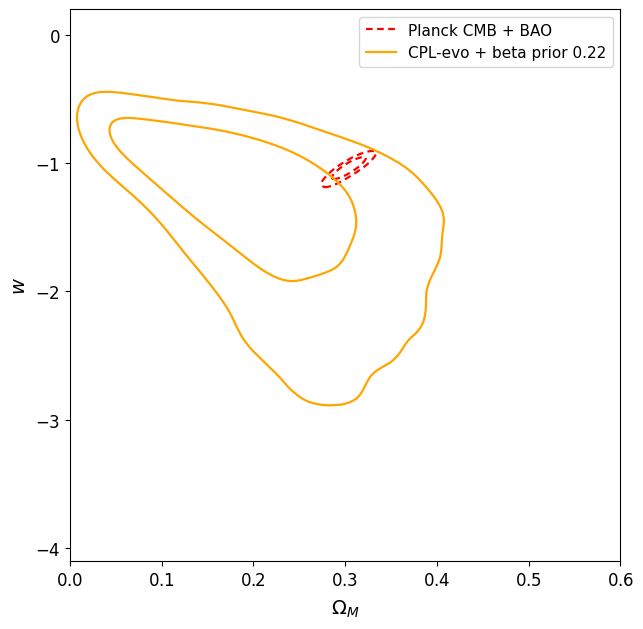

In [23]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------- Planck chain ----------
planck_root = r"/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO"

def ensure_omegam_and_w(samples):
    """Ensure 'omegam' and 'w' exist; derive if needed; set nice labels."""
    P = samples.getParams()
    names = {p.name for p in samples.getParamNames().names}
    if 'w' not in names and hasattr(P, 'w0'):
        samples.addDerived(P.w0, name='w', label='w')
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2, name='omegam', label=r'\Omega_M')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2, name='omegam', label=r'\Omega_M')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_M')
    try: samples.setLabel('omegam', r'\Omega_M')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

planck = loadMCSamples(planck_root, settings={'ignore_rows':0.3}, no_cache=True)
planck = ensure_omegam_and_w(planck)

# ---------- Local NumPy chain -> MCSamples ----------
# Adjust these if needed
base_dir    = r'/home/astrodust/SG/sgl_cosmo/GLS_cosmo01'
evo_label   = r"CPL"
prior_label = r"0.22"
samples_file = os.path.join(base_dir, 'Output', f'{evo_label}-{prior_label}',
                            f"mcmc_cosmop2D-{evo_label}-{prior_label}.npy")

arr = np.load(samples_file)  # shape (nwalkers, nsteps, ndim) or (nsamp, ndim)

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w')):
    """Flatten NumPy chain and wrap into getdist.MCSamples with proper names/labels."""
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr

    # If your columns are [ΩM, w0], this is fine. If reversed, swap here:
    # flat = flat[:, [1, 0]]

    names  = list(order)                 # tokens
    labels = [r'\Omega_M', 'w']          # LaTeX
    return MCSamples(samples=flat, names=names, labels=labels)

local = numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w'))

# ---------- Combined plot: 1σ + 2σ, no fill ----------
g = plots.get_subplot_plotter(width_inch=6.4)
g.settings.num_plot_contours = 2    # 68% and 95%
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11
g.settings.linewidth = 1.6

# Planck: dashed
# Local:  solid
g.plot_2d(
    [planck, local],
    ['omegam', 'w'],
    filled=False,
    colors=['red', 'orange'],
    line_args=[{'ls':'--','lw':1.6}, {'ls':'-','lw':1.6}],
    legend_labels=['Planck CMB + BAO', f'{evo_label}-evo + beta prior {prior_label}'],
)

ax = g.subplots[0, 0]
ax.set_xlim(0.0, 0.6)
ax.set_ylim(-4.1, 0.2)
ax.set_xlabel(r'$\Omega_M$')
ax.set_ylabel(r'$w$')

g.add_legend(['Planck CMB + BAO', f'{evo_label}-evo + beta prior {prior_label}'],
             legend_loc='upper right', colored_text=False)

g.export('combined_omegam_w_1sigma_2sigma_nofill.png')
print('Saved: combined_omegam_w_1sigma_2sigma_nofill.png')
